<a href="https://colab.research.google.com/github/yume2014-ang/yarn-classifier-app/blob/main/Yarn_Material_Classification_Model_ver_11302025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ランタイムの変更

[ランタイム] タブより、[ランタイムのタイプを変更] > [T4GPU] を選択。

# 🧶必要なライブラリのインポート

In [1]:
!pip install -q split-folders japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 29.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


- split-folders：クラスの比率を保持したまま分割


In [2]:
import japanize_matplotlib
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import optimizers

# 乱数シードの固定
SEED = 0    # 再現性のため

# 🧶データセットの準備と確認

- データのアップロード時間を短縮するため、Googleドライブ上にデータを置き、コードでDriveをマウントする
- 毛糸の画像データを読み込み、「訓練用(Train)」「検証用(Val)」の2つのグループに分け、パイプラインを構築。

```
💡 以下のようなフォルダリングがされている
-- data フォルダ
    |-- images フォルダ
          |-- cotton フォルダ：cotton毛糸の画像
          |-- wool フォルダ：wool毛糸の画像
```

## ⭐フォルダ構造から自動的にデータセットを作成

- drive.mount()の引数に、'/content/drive' のように先頭にスラッシュ（/）が必要（スラッシュがない＝相対パスを指定）

In [3]:
from google.colab import drive

# Google Drive全体をマウント
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import splitfolders

# --- 設定 ---
DATA_DIR = "/content/drive/MyDrive/YarnClass/data/images"    # 画像フォルダのルートパス
INPUT_DIR = DATA_DIR                # 元データのパス
OUTPUT_DIR = "/content/drive/MyDrive/YarnClass/data/images_split"    # 分割後の保存先パス

# 訓練セット(全体の80%)：検証セット(20%)
# 80%, 20% に層化分割してコピーする
# ratio=(.8, .2) で指定
splitfolders.ratio(INPUT_DIR,
                   output=OUTPUT_DIR,
                   seed=0,
                   ratio=(.8, .2),
                   group_prefix=None)

Copying files: 252 files [01:43,  2.44 files/s]


    ＊クラスの比率を保ったまま分割

    data/images_split/
    ├── train/
    │      ├── cotton/ (全体の80%)
    │      └── wool/   (全体の80%)
    └── val/
            ├── cotton/ (全体の20%)
            └── wool/   (全体の20%)


In [5]:
# --- 設定 ---
IMG_SIZE = (224, 224)       # EfficientNet-B0の入力サイズ
BATCH_SIZE = 16             # バッチサイズ

# --- 1. 訓練・検証データの読み込み ---
# 各フォルダから個別にデータを読み込み、自動的にラベルを割り当てる
#   ・image_dataset_from_directory : 自動的にデータ読込・デコード(default:color_mode='rgb')・リサイズ・バッチ化まで完了
#   ・検証用(shuffle=False)：評価の際は毎回同じ順番でデータを評価し、性能を正しく比較・記録）

# 訓練セット
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/YarnClass/data/images_split/train",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'    # ラベルを整数(0, 1, ...)で取得：クラスを数値にマッピング
)

# 検証セット
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/YarnClass/data/images_split/val",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False   # 評価データはシャッフルしない
)

# クラス名の確認
class_names = train_ds_raw.class_names
print(f"Classes: {class_names}")

print(f"Train batches: {tf.data.experimental.cardinality(train_ds_raw)}")
print(f"Val batches: {tf.data.experimental.cardinality(val_ds_raw)}")


# --- 2. 前処理関数の定義 ---
# EfficientNet-B0用の前処理を行う関数
#   preprocess_input：EfficientNet用の正規化、ピクセル値をモデルが学習した時と同じ範囲（例: -1〜1）に変換
def preprocess(images, labels):
    return preprocess_input(images), labels

# --- 3. パイプラインの構築 ---
# 各データセットに前処理を適用し、パフォーマンス最適化の設定を行う
AUTOTUNE = tf.data.AUTOTUNE     # tf.data.AUTOTUNE : 変換処理をCPUで並列実行し、高速化するおまじない

train_ds = train_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE)    # バッチごと前処理（正規化）を適用
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 200 files belonging to 2 classes.
Found 52 files belonging to 2 classes.
Classes: ['cotton', 'wool']
Train batches: 13
Val batches: 4


【tf.data を使う上での高速化テクニック】
1. **.map()** で前処理を並列化
2. **.cache()** で2周目以降の処理を省略（データをメモリにキャッシュし、2回目以降のエポックでの読み込みを高速化）
3. **.prefetch(AUTOTUNE)** でGPUの待ち時間をゼロ（学習中に次のバッチを裏で準備させておき、GPUの待ち時間を減らす）

---

- train_ds.cache() を（ファイル名を指定せずに）呼び出すと、TensorFlowは**前処理済みのデータセット全体をPCのメモリ（RAM）に保存しよう**と試みます。
- データが巨大すぎてメモリに乗り切らない場合
    1. ディスクにキャッシュする（推奨される代替案）
        - cache() にファイルパス（保存場所）を指定すると、メモリ(RAM)の代わりに低速なディスク(SSD/HDD)にキャッシュファイルを作成。
        - メリット: メモリを圧迫せず、クラッシュの心配がない。
        - デメリット: RAMからの読み出しよりは遅い。
        - 毎回 .map() で「画像のデコード＋リサイズ＋前処理」をやり直すよりは格段に速い。
    2. キャッシュを使わない（最終手段）
        - データが巨大すぎる（数百万枚の画像や動画）場合は、cache() 自体を諦め、prefetch() だけで対処（train_ds.prefetch(buffer_size=AUTOTUNE)）。
        - 動作: 毎エポック、律儀に「画像読み込み → 前処理 → バッチ化」を実行。
        - 高速化: prefetch() がGPUの計算中にCPUで↑の準備を「先読み」してくれるので、GPUの待ち時間は最小限に抑えられる。

# 🧶モデルの定義・学習

【転移学習モデル　構築方針】
1. データ拡張 (Data Augmentation):
    - 毛糸の質感を損なわないよう、左右反転、ごくわずかな回転、ごくわずかなズームのみを使用。
    - これらの処理はモデルの先頭にレイヤーとして組み込む。

2. 転移学習 (Transfer Learning):
    - データ量が各クラス100枚程度と少ないため、過学習を防ぐことが最優先。
    - EfficientNetB0 の重みは ImageNet学習済みのものを使用 し、ベース部分は 完全に凍結（trainable = False）。
    - GlobalAveragePooling2D の後に、新しい分類層（Dense）のみを追加し、この部分だけを学習。

3. 安定化と過学習対策:
    - 分類層の直前に Dropout を挿入し、過学習を抑制。
    - オプティマイザの学習率は小さめ（1e-4）に設定し、安定した学習を目指す。
    - エポック数も少なめ（15）に設定。

In [6]:
# 追加: 早期終了用
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# --- ユーザー定義済みの変数（確認用） ---
# IMG_SIZE = (224, 224)
# SEED = 0

# --- 0. クラス数の取得 ---
# image_dataset_from_directory が自動的に検出したサブフォルダ（クラス）の数を取得
try:
    num_classes = len(train_ds_raw.class_names)
    print(f"✅ クラス数を取得しました。クラス数: {num_classes}")
except NameError:
    print("⚠️ エラー: 'train_ds_raw' が定義されていません。")
    print("     クラス数を手動で設定してください (例: num_classes = 5)")

# --- 1. データ拡張(Data Augmentation)レイヤーの定義 ---
# 繊維の質感を残すため、控えめな設定
#   質感を保持するため、色相、彩度、コントラストの変更は避け、
#   幾何学的な変換（反転、回転、ズーム）のみに留めた
# ★追加: 照明条件の変化に対応するため、コントラストを少しランダム化
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED), # horizontal=左右反転（水平反転）
    layers.RandomRotation(0.1, seed=SEED), # 10%の範囲 (約36度) でランダムに回転
    layers.RandomZoom(0.1, seed=SEED),     # 10%の範囲でランダムにズーム
    layers.RandomContrast(0.1, seed=SEED), # <- 追加（データ拡張強化）
], name="data_augmentation")


# --- 2. モデルの構築 ---
def build_model(input_shape, num_classes):
    """
    EfficientNetB0内部を展開して接続する転移学習モデル
    """

    # --- 1. 入力層とデータ拡張 ---
    inputs = layers.Input(shape=input_shape, name="input_layer")
    x = data_augmentation(inputs)    # データ拡張

    # --- 2. ベースモデル (EfficientNetB0) の統合 ---
    #   ポイント: input_tensor=x を指定することで、
    #   データ拡張後のテンソルをEfficientNetの入力として直結させる
    base_model = EfficientNetB0(
        include_top=False,  # ImageNetの分類層（一番上）は使わない
        weights='imagenet', # ImageNetで学習済みの重みを使用
        input_tensor=x  # <--- ここが変更点（前の層の出力を渡す）
    )

    # ベースモデルの凍結設定
    #   データ量が少ないため、ベースモデルの重みは更新しないように設定
    #   EfficientNetB0がImageNetで学習した特徴抽出の知識をそのまま利用
    base_model.trainable = False

    # --- 3. 特徴量の抽出と分類層 ---
    #   base_model(x) ではなく、base_model.output を使って続きを書く
    # EfficientNetの最終層の出力を取得
    #   input_tensorを指定した場合、base_model自体がGraphの一部になるため、
    #   そのoutputプロパティが次の層への入力になる
    x = base_model.output

    # 特徴量の集約（プーリング）
    # ベースモデルからの特徴量マップを、1次元のベクトルに変換
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

    # バッチ正規化 (学習の安定化のため)
    x = layers.BatchNormalization(name="batch_norm")(x)

    # 過学習防止 (Dropout)
    # 20%のニューロンをランダムに無効化
    #   学習中にランダムで20%の接続を無効化
    #   これにより、モデルが特定の（少数の）特徴に過度に依存するのを防ぎ、
    #   汎化性能（未知のデータへの対応力）を高める
    # ★追加: Dropout率を 0.2 -> 0.5 に変更 (より厳しくする)
    x = layers.Dropout(0.5, name="dropout_layer")(x) # <- 過学習対策の強化

    # 最終出力層 (新しい分類層)
    #   ユニット数 = クラス数
    # ★追加: 最終出力層に L2正則化 (Weight Decay) を追加
    #         これにより、特定の重みだけが極端に大きくなる(暗記する)のを防ぐ
    outputs = layers.Dense(
        num_classes,
        kernel_regularizer=regularizers.l2(0.01), # <- L2正則化
        name="output_layer"
    )(x)

    # モデル定義
    # input_tensorで繋がっているため、inputsからoutputsまで一本道になります
    model = models.Model(inputs=inputs, outputs=outputs)

    return model


# --- 3. モデルのインスタンス化とコンパイル ---
IMG_SHAPE = IMG_SIZE + (3,) # (224, 224, 3)

model = build_model(IMG_SHAPE, num_classes)

# 学習率(LR)を小さめに設定 (安定性重視)
#   学習率が大きすぎると、学習済みの重みが壊れてしまい、学習が不安定に
#   凍結したモデルの上位層をそっと学習させるため、非常に小さい学習率（1e-4）から始めるのが定石
LR = 0.0001 # 1e-4

model.compile(
    # オプティマイザ: Adam (学習率をカスタマイズ)
    optimizer=optimizers.Adam(learning_rate=LR),

    # 損失関数:
    # label_mode='int' のため 'SparseCategoricalCrossentropy' を使用
    # 出力層に活性化関数を適用していないため 'from_logits=True' を指定
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),

    # 評価指標: 正解率
    metrics=['accuracy']
)


# --- 4. Callbacks (早期終了) の設定 ---
# ★追加: グラフを見て「悪くなり始めた」ところで止める機能
early_stopping = EarlyStopping(
    monitor='val_loss',         # 監視する値 (検証損失)
    patience=5,                 # 改善しなくなってから何回我慢するか
    restore_best_weights=True,  # 終了時、最も良かった頃の重みに戻す(超重要)
    verbose=1
)


# --- 5. 学習の実行 ---
# エポック数 (学習の繰り返し回数) を設定
# EarlyStoppingがあるため、Epoch数は少し多めに設定しておいてOK
EPOCHS = 100

print(f"\n--- 学習開始 (Max Epochs: {EPOCHS}, LR: {LR}) ---")

history = model.fit(
    train_ds,               # 訓練データ
    epochs=EPOCHS,
    validation_data=val_ds, # 検証データ
    callbacks=[early_stopping] # <- ここに Callbacks セット
)


print("✅ 学習が完了しました。")

✅ クラス数を取得しました。クラス数: 2
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- 学習開始 (Max Epochs: 100, LR: 0.0001) ---
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5341 - loss: 1.1952 - val_accuracy: 0.4231 - val_loss: 0.8197
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.5555 - loss: 1.0644 - val_accuracy: 0.4423 - val_loss: 0.7982
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6102 - loss: 0.8741 - val_accuracy: 0.5385 - val_loss: 0.7804
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5933 - loss: 1.0924 - val_accuracy: 0.5577 - val_loss: 0.7613
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6434 - loss: 0.8921 - val_accuracy: 0.5577 - val_loss: 0.7412
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6582 - loss: 0.8534 - val_accuracy: 0.5769 - val_loss: 0.7222
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.7061 - loss: 0.7808 - val_accuracy: 0.6346 - val_

⭐ 数値的な安定性を重視するため、モデルの訓練時に最終層にsoftmaxは適用しない。

これにより、損失関数がsoftmaxの計算と損失の計算を最適化された形で統合して実行し、log(0)のような計算エラーを避けることができる。これがKerasで推奨される設定。

⭐ モデルの損失関数でfrom_logits=Trueを使用している場合、予測時にはモデルの出力に明示的にSoftmaxを適用する必要がある。

1. 学習中・評価中（損失計算時）: SparseCategoricalCrossentropy(from_logits=True) を使用しているため、Kerasは内部的にSoftmaxを適用して確率を計算し、損失を計算。このプロセスは数値的な安定性を保つように最適化されているため、この段階でユーザーが明示的にSoftmaxを適用する必要はない。
2. 予測時（model.predict()使用時）: model.predict() の出力は、活性化関数が適用されていない**生のロジット（logit）**。これらはまだ確率ではないため、各クラスの予測確率（0から1の間の値で、合計が1になる）を得るためにはモデルの出力に**tf.nn.softmax**を適用する必要がある。

# 🧶学習の推移（正解率と損失）を確認

- 学習実行後、「学習がうまくいったか」をグラフで可視化 → モデルをファイルに保存

    - 学習履歴（history）を使って学習曲線（正解率と損失の推移）をプロット
    - model.fit() から返された history オブジェクトを使って、学習の推移（正解率と損失）をプロット

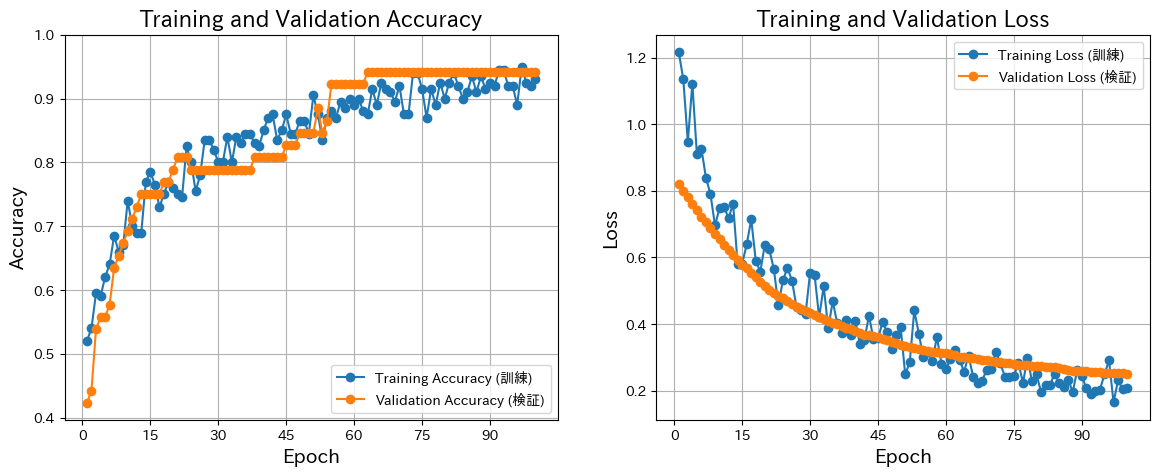

In [7]:
# --- 1. history オブジェクトからメトリクスを取得 ---

from matplotlib.ticker import MaxNLocator

# history.history は辞書型です
# キー: 'loss', 'accuracy', 'val_loss', 'val_accuracy'
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# エポック数 (横軸用)
# history.epoch は 0 から始まるエポックのリスト
# history.epoch (0, 1, 2...) の各要素に +1 をして (1, 2, 3...) に変換
epochs_range = [e + 1 for e in history.epoch]

# --- 2. グラフの作成 (2つのグラフを並べて表示) ---

plt.figure(figsize=(14, 5)) # グラフ描画領域のサイズを横長に設定

# --- 2a. 正解率 (Accuracy) のグラフ ---
plt.subplot(1, 2, 1) # 1行2列のグラフの1番目
plt.plot(epochs_range, acc, label='Training Accuracy (訓練)', marker='o')   # 点(marker)をつけて位置を明確にする
plt.plot(epochs_range, val_acc, label='Validation Accuracy (検証)', marker='o')

# 軸ラベルとタイトルの設定
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

# 凡例の表示
plt.legend(loc='lower right')

# グリッド線を表示して値を読みやすくする
plt.grid(True)

# X軸の目盛りを整数に固定（ズレ防止のため推奨）
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# Y軸の範囲を (0, 1) に設定 (Accuracyは 0から1 のため)
plt.ylim([min(plt.ylim()), 1])


# --- 2b. 損失 (Loss) のグラフ ---
plt.subplot(1, 2, 2) # 1行2列のグラフの2番目
plt.plot(epochs_range, loss, label='Training Loss (訓練)', marker='o')   # 点(marker)をつけて位置を明確にする
plt.plot(epochs_range, val_loss, label='Validation Loss (検証)', marker='o')

# 軸ラベルとタイトルの設定
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)

# 凡例の表示
plt.legend(loc='upper right')

# グリッド線を表示して値を読みやすくする
plt.grid(True)

# X軸の目盛りを整数に固定
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# グラフの表示
plt.show()

📖 グラフの見方

1. 左側 (Accuracy):
- Training Accuracy (訓練) (青線): 訓練データに対する正解率。エポックが進むにつれて上がっていくのが理想です。
- Validation Accuracy (検証) (オレンジ線): 検証データ（モデルが学習中に見ていないデータ）に対する正解率。これがモデルの「本当の性能」に近い指標です。

2. 右側 (Loss):
- Training Loss (訓練) (青線): 訓練データに対する損失（間違いの度合い）。エポックが進むにつれて下がっていくのが理想です。
- Validation Loss (検証) (オレンジ線): 検証データに対する損失。

---

🩺 健康診断のポイント
- 理想的な状態:

    訓練データと検証データの両方の線（青とオレンジ）が、そろって改善している（Accuracyは上がり、Lossは下がる）。

- 過学習 (Overfitting) の兆候:

    Training Accuracy (青) は上がり続けるが、Validation Accuracy (オレンジ) が途中で頭打ちになるか、下がり始める。

    Training Loss (青) は下がり続けるが、Validation Loss (オレンジ) が途中で底を打って、上がり始める。

        もし過学習の兆候が見られたら、Dropoutの率を増やす（例: 0.2 -> 0.3）や、エポック数を早めに切り上げる（例: 15 -> 10）などの対策を考えます。

In [8]:
import pandas as pd

# history.history 辞書を DataFrame に変換
hist_df = pd.DataFrame(history.history)

# インデックスを 0 始まりではなく 1 始まり (Epoch 1~) に直して表示
hist_df.index = hist_df.index + 1
hist_df.index.name = 'Epoch'

# 全データを表示
print(hist_df)

# （参考）もしCSVファイルとして保存したい場合
# hist_df.to_csv('training_history.csv')

       accuracy      loss  val_accuracy  val_loss
Epoch                                            
1         0.520  1.216163      0.423077  0.819749
2         0.540  1.134949      0.442308  0.798184
3         0.595  0.947452      0.538462  0.780441
4         0.590  1.121740      0.557692  0.761317
5         0.620  0.910062      0.557692  0.741222
...         ...       ...           ...       ...
96        0.890  0.291208      0.942308  0.251923
97        0.950  0.165194      0.942308  0.251512
98        0.925  0.230461      0.942308  0.252022
99        0.920  0.204614      0.942308  0.251502
100       0.930  0.208916      0.942308  0.250113

[100 rows x 4 columns]


## Loss：なぜ 「ログに表示された数値（0.9794）」と「グラフの数値（1.0363）」が食い違っていたのか

- Keras/TensorFlowの「仕様」によるもの：原因： 「移動平均」と「全体平均」の違い
    - 見ているタイミングと計算方法が違うため

        - ログ (model.fit の表示): 学習が進むにつれてリアルタイムで更新される 「その時点までの移動平均（または直近のバッチの値）」 を表示しています。学習が進む（バッチが進む）ごとにLossは下がっていくため、エポックの最後の方に表示される数値は、最も下がった状態（低い値）になりやすいです。

        - グラフ (history オブジェクト): そのエポックの 「最初から最後までの全てのデータの平均値」 です。学習初期（エポックの開始直後）のまだ賢くない状態の高いLoss（失敗）も平均に含まれるため、最後の方の良い値だけを見るよりも数値が高く（悪く）なります。
    - 分かりやすい例え：マラソン

            マラソンのタイム（Loss）で考えてみましょう（低いほうが優秀）。
            スタート直後: まだ調子が出ず、遅いペース（Loss = 1.5）で走っています。
            ゴール手前: 調子が上がり、すごい速いペース（Loss = 0.9）で走っています。
            ログが見ていたもの: ゴールした瞬間のスピード計。「おっ、今は 0.9 のペースだね！」
            グラフが見ているもの: レース全体の平均タイム。「最初は遅かったから、平均すると 1.03 だね。」

--- データの数値確認 ---
Epoch 1 - Train Loss (実際の値): 1.2161626815795898
Epoch 1 - Val Loss   (実際の値): 0.8197488188743591
Epoch 1 - Train Accuracy      : 0.5199999809265137


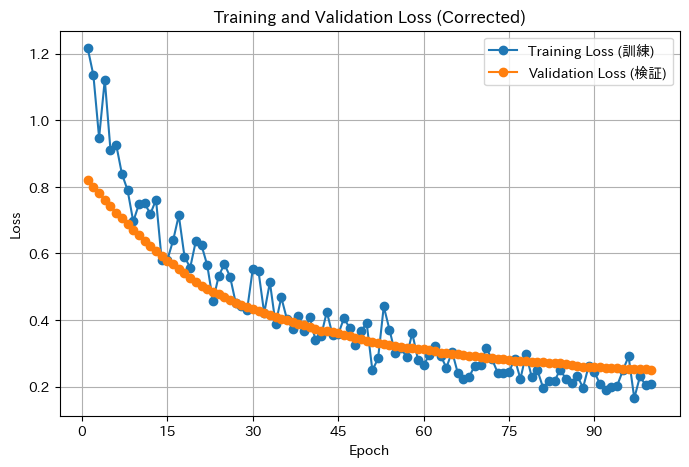

In [9]:
# 1. 実際の数値をプリントして確認する
print("--- データの数値確認 ---")
print(f"Epoch 1 - Train Loss (実際の値): {history.history['loss'][0]}")
print(f"Epoch 1 - Val Loss   (実際の値): {history.history['val_loss'][0]}")
print(f"Epoch 1 - Train Accuracy      : {history.history['accuracy'][0]}")

# 2. Lossグラフだけを単独で描画し直す（変数の指定ミス防止）
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# エポック軸の再定義（念のため）
epochs_range = [e + 1 for e in history.epoch]
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label='Training Loss (訓練)', marker='o') # 点(marker)をつけて位置を明確にする
plt.plot(epochs_range, val_loss, label='Validation Loss (検証)', marker='o')

plt.title('Training and Validation Loss (Corrected)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True) # グリッド線を表示して値を読みやすくする
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

In [10]:
import sys
print("Pythonのバージョン:", sys.version)

Pythonのバージョン: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


# 🎄⛄混同行列の作成と表示

- モデルがどのクラスを正しく分類し、どのクラスを誤って分類したかを視覚的に確認。
- 正解率だけではわからない、詳細な分類性能を把握。

In [11]:
# 混同行列を作成
import numpy as np
from sklearn.metrics import confusion_matrix
# import matplotlib.pyplot as plt
import seaborn as sns

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 726ms/step


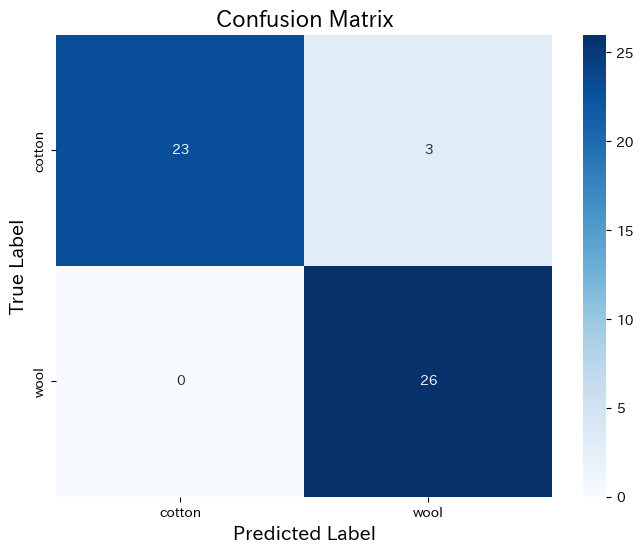

In [12]:
# --- 1. 検証データセットから予測と正解ラベルを取得 ---

# モデルから予測結果（ロジット）を取得
# predict()はバッチごとに処理し、結果を返す
# tf.concat() で全てのバッチのロジットを結合
val_logits = model.predict(val_ds)

# ロジットをSoftmaxに適用して確率に変換
val_probabilities = tf.nn.softmax(val_logits).numpy()

# 最も高い確率を持つクラスのインデックスを取得（予測クラス）
val_predictions = np.argmax(val_probabilities, axis=1)

# 検証データセットから真のラベルを取得
# val_ds は (画像, ラベル) のタプルのバッチなので、ラベルだけを取り出して結合
val_true_labels = []
for images, labels in val_ds_raw:
    val_true_labels.extend(labels.numpy())
val_true_labels = np.array(val_true_labels)

# --- 2. 混同行列を計算 ---
cm = confusion_matrix(val_true_labels, val_predictions)

# --- 3. 混同行列をヒートマップで表示 ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,        # セルに数値を表示
            fmt='d',           # 数値を整数としてフォーマット
            cmap='Blues',      # カラーマップ（青系のグラデーション）
            xticklabels=class_names, # X軸のラベルをクラス名に設定
            yticklabels=class_names) # Y軸のラベルをクラス名に設定

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()

抽出された画像の枚数: 3枚


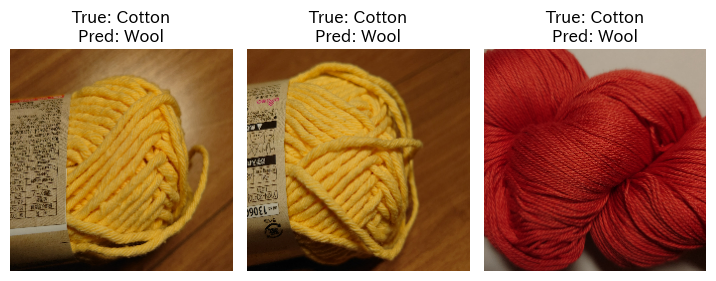

In [13]:
# 間違えた画像を抽出・表示するコード①
# cotton Ver.

# --- 設定：どの間違いを探すか ---
# ヒートマップの左上が cotton(0), 右下が wool(1) なので
target_true_label = 0  # 正解: Cotton
target_pred_label = 1  # 予測: Wool (間違えたラベル)

mistaken_images = []

# --- 1. データセットを回して画像を収集 ---
# val_ds をバッチごとに取り出す
for images, labels in val_ds:
    # 予測を行う
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    # バッチ内の各画像についてチェック
    for i in range(len(labels)):
        true_lbl = labels[i].numpy() # 正解ラベル
        pred_lbl = pred_labels[i]    # 予測ラベル

        # 「正解がCotton」かつ「予測がWool」の場合だけ画像を保存
        if true_lbl == target_true_label and pred_lbl == target_pred_label:
            mistaken_images.append(images[i].numpy())

# --- 2. 間違えた画像を表示 ---
print(f"抽出された画像の枚数: {len(mistaken_images)}枚")

if len(mistaken_images) > 0:
    plt.figure(figsize=(12, 6))
    for i, img in enumerate(mistaken_images):
        # 最大10枚まで表示（レイアウト崩れ防止）
        if i >= 10: break

        plt.subplot(2, 5, i + 1) # 2行5列で表示

        # 画像データの値が 0-1 の範囲ならそのまま、0-255なら int型に変換して表示
        if img.max() > 1.0:
            img = img.astype("uint8")

        plt.imshow(img)
        plt.title(f"True: Cotton\nPred: Wool")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("条件に合う画像が見つかりませんでした。インデックス番号を確認してください。")


In [14]:
# 間違えた画像を抽出・表示するコード②
# wool Ver.

# --- 設定：どの間違いを探すか ---
# ヒートマップの左上が cotton(0), 右下が wool(1) なので
target_true_label = 1  # 正解: Wool
target_pred_label = 0  # 予測: Cotton (間違えたラベル)

mistaken_images = []

# --- 1. データセットを回して画像を収集 ---
# val_ds をバッチごとに取り出す
for images, labels in val_ds:
    # 予測を行う
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    # バッチ内の各画像についてチェック
    for i in range(len(labels)):
        true_lbl = labels[i].numpy() # 正解ラベル
        pred_lbl = pred_labels[i]    # 予測ラベル

        # 「正解がWool」かつ「予測がCotton」の場合だけ画像を保存
        if true_lbl == target_true_label and pred_lbl == target_pred_label:
            mistaken_images.append(images[i].numpy())

# --- 2. 間違えた画像を表示 ---
print(f"抽出された画像の枚数: {len(mistaken_images)}枚")

if len(mistaken_images) > 0:
    plt.figure(figsize=(12, 6))
    for i, img in enumerate(mistaken_images):
        # 最大10枚まで表示（レイアウト崩れ防止）
        if i >= 10: break

        plt.subplot(2, 5, i + 1) # 2行5列で表示

        # 画像データの値が 0-1 の範囲ならそのまま、0-255なら int型に変換して表示
        if img.max() > 1.0:
            img = img.astype("uint8")

        plt.imshow(img)
        plt.title(f"True: Wool\nPred: Cotton")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("条件に合う画像が見つかりませんでした。インデックス番号を確認してください。")


抽出された画像の枚数: 0枚
条件に合う画像が見つかりませんでした。インデックス番号を確認してください。


# 🧶EfficientNetB0のレイヤー名を確認

- 'efficientnetb0' → モデル作成時にネスト構造になっている
- 'top_activation' → ターゲット層が見えている！

In [15]:
# --- モデル構造の確認 ---
print("--- モデルの構造 ---")
model.summary()

--- モデルの構造 ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,067,499 (15.52 MB)

 Trainable params: 5,122 (20.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 10,246 (40.03 KB)

# 🧶モデルをファイルに保存

In [16]:
# 学習したモデルを保存
#   ＊'models'フォルダがなければ先にフォルダを作成
model.save('/content/drive/MyDrive/YarnClass/models/yarn_material_model.keras')